In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [14]:
df_cars = pd.read_csv("Datos/car_prices.csv")
df_cars = df_cars[['sellingprice', 'odometer', 'year']]

for col in ['sellingprice', 'odometer', 'year']:
    df_cars[col] = pd.to_numeric(df_cars[col], errors = 'coerce')

df_cars = df_cars.dropna(subset = ['sellingprice', 'odometer', 'year'])

print(df_cars.isna().sum())
df_cars.head()

sellingprice    0
odometer        0
year            0
dtype: int64


,sellingprice,odometer,year
0,21500.0,16639.0,2015
1,21500.0,9393.0,2015
2,30000.0,1331.0,2014
3,27750.0,14282.0,2015
4,67000.0,2641.0,2014


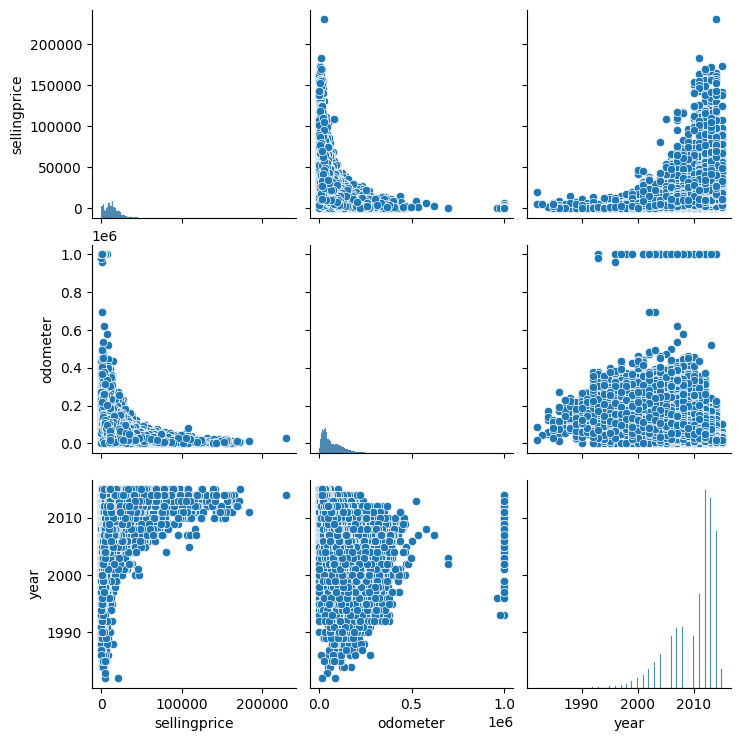

In [15]:
sns.pairplot(df_cars)
plt.show()

In [16]:
x = df_cars[['odometer', 'year']]
y = df_cars['sellingprice']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Interceptos:", model.intercept_)
print("Coeficientes:", dict(zip(x.columns, model.coef_)))

Interceptos: -1661776.1805777736
Coeficientes: {'odometer': np.float64(-0.058258227199566075), 'year': np.float64(835.4910232898394)}


In [19]:
x_vif = add_constant(x)

vif_df = pd.DataFrame({
    "Variable": x_vif.columns,
    "VIF": [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])]
})
vif_df

,Variable,VIF
0,const,640062.866653
1,odometer,2.482129
2,year,2.482129


In [20]:
y_train_pred = model.predict(x_train)
residuals = (y_train - y_train_pred).values.ravel()

dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.3f}")

Durbin-Watson: 2.005


In [21]:
y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("Error cuadrático medio:", mse)

R2: 0.3911255113403246
Error cuadrático medio: 56871197.03974272
